### LAB 8: 07 April 2026

1. Compare performance of logistic regression classifier on 
Iris, and digits dataset of sklearn by training set size from 1% to 100%. 
Plot the accuracy vs training set size graph.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics


### IRIS Dataset

In [5]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
X = iris.data
y = iris.target

In [ ]:
def learning_curve(acc, size, set):
    plt.plot(size, acc, color="green", marker=".")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(f"Learning curve for Logistic regression for {set} dataset")
    plt.grid(True)
    plt.show() 


def learning_curve_compressed(acc, size, set, threshold=0.0001, counter=5):

    filtered_acc = []
    filtered_size = []
    
    small_change_count = 0

    for i in range(len(acc)):
        if i > 0:
            change = abs(acc[i] - acc[i-1])
            
            if change < threshold:
                small_change_count += 1
            else:
                small_change_count = 0

            if small_change_count >= counter:
                break
        
        filtered_acc.append(acc[i])
        filtered_size.append(size[i])

    plt.plot(filtered_size, filtered_acc, color="blue", marker=".")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(f"Learning curve compressed for Logistic Regression ({set})")
    plt.grid(True)
    plt.show()

In [92]:
def logistic_varied_size(X, y):
    acc = []
    size = []
    for i in range(98, 0, -1):
        i = 0.01 * i
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=i, random_state=42)
        logreg = LogisticRegression()
        logreg.fit(X_train, y_train)
        y_pred=logreg.predict(X_test)
        a = metrics.accuracy_score(y_test, y_pred)
        acc.append(a)
        size.append(1 - i)
    
    return acc, size

c:\Users\verma\projects\Data-Mining\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


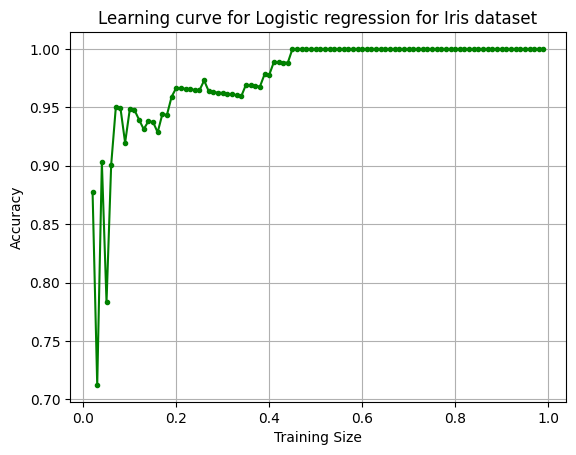

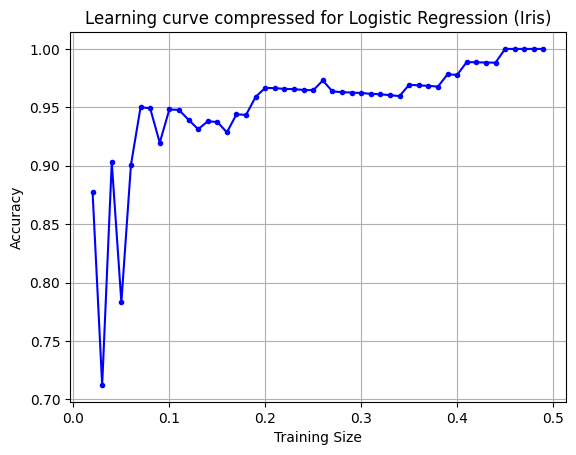

In [93]:
acc, size = logistic_varied_size(X, y)
learning_curve(acc, size, "Iris")
learning_curve_compressed(acc, size, "Iris")

### DIGITS Dataset 

In [ ]:
digits = datasets.load_digits()

In [82]:
X2 = digits.data
y2 = digits.target

c:\Users\verma\projects\Data-Mining\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\verma\projects\Data-Mining\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules

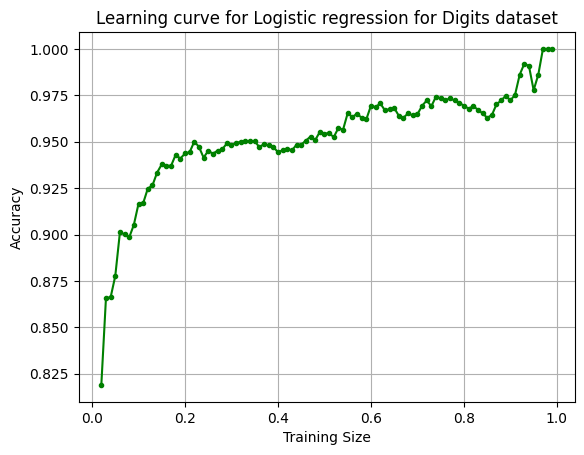

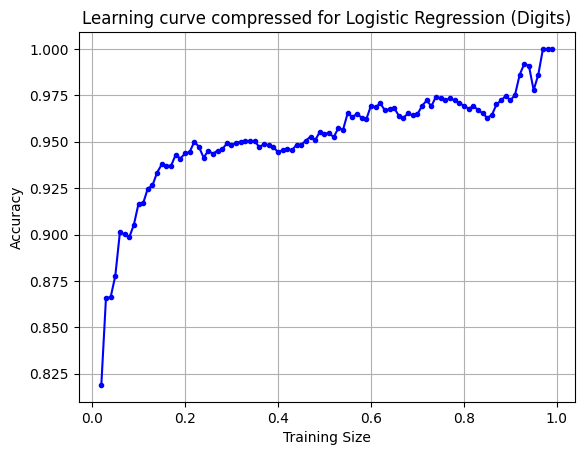

In [95]:
acc, size = logistic_varied_size(X2, y2)
learning_curve(acc, size, "Digits")
learning_curve_compressed(acc, size, "Digits")